## INFS 772 Assignment 4
### Total 10 points (6 tasks)

# Image Classification with MNIST Dataset

This short introduction uses [Keras](https://www.tensorflow.org/guide/keras/overview) to:

1. Build a neural network that classifies images.
2. Train this neural network.
3. And, finally, evaluate the accuracy of the model.

Download and install TensorFlow 2. Import TensorFlow into your program:

Note: Upgrade `pip` to install the TensorFlow 2 package. See the [install guide](https://www.tensorflow.org/install) for details.

In [2]:
import tensorflow as tf

from tensorflow.keras.datasets import mnist #from Keras download the mnist dataset
from tensorflow.keras.models import Sequential # import the sequential model
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense # import the Dense(Fully connected) layer
from tensorflow.keras.optimizers import RMSprop # import rmsprop optimizer
from tensorflow.keras.utils import to_categorical # prepare the labels
import matplotlib.pyplot as plt #import plot as plt

In [3]:
tf.__version__

'2.15.0'

Load and prepare the [MNIST dataset](http://yann.lecun.com/exdb/mnist/). Convert the samples from integers to floating-point numbers:

In [4]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 [==============================] - 0s 0us/step


Build the `tf.keras.Sequential` model by stacking layers. Choose an optimizer and loss function for training:

## Task 1: Build Neural Network Using the following code samples (2 points)

```python

model = Sequential() # make our model Sequential

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(50, activation = "relu")) # add a hidden layer
model.add(Dense(10, activation = 'softmax')) # add an output layer

```
### Required Specification for the Hidden Layers

Dense 64 --> Dense 32

Total params: 52,650


In [5]:
# your codes here

model = Sequential() # make our model Sequential
model.add(Flatten(input_shape=(28, 28))) # flatten the inputs
model.add(Dense(64, activation = "relu")) # add a hidden layer
model.add(Dense(32, activation = "relu")) # add a hidden layer
model.add(Dense(10, activation = 'softmax')) # add an output layer

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 52650 (205.66 KB)
Trainable params: 52650 (205.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The following cell is not required. Remove it if it doesn't work under your environment

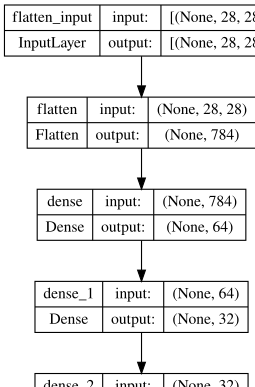

In [6]:
from IPython.display import SVG
from tensorflow.keras.utils import model_to_dot

SVG(model_to_dot(model, show_shapes= True, show_layer_names=True, dpi=65).create(prog='dot', format='svg'))

## Task 2: Test the Model Architecture (2 points)

All codes are provided and make sure they produce the expected outputs

For each example the model returns a vector of "[logits](https://developers.google.com/machine-learning/glossary#logits)" or "[log-odds](https://developers.google.com/machine-learning/glossary#log-odds)" scores, one for each class.

In [7]:
predictions = model(x_train[:1]).numpy()
predictions

array([[0.10206334, 0.15535426, 0.06613677, 0.06597346, 0.0759371 ,
        0.12095649, 0.18050328, 0.06543312, 0.08175036, 0.08589184]],
      dtype=float32)

The `tf.nn.softmax` function converts these logits to "probabilities" for each class:

In [8]:
tf.nn.softmax(predictions).numpy()

array([[0.1001325 , 0.1056134 , 0.09659895, 0.09658317, 0.0975503 ,
        0.10204232, 0.10830316, 0.096531  , 0.09811904, 0.09852623]],
      dtype=float32)

Note: It is possible to bake this `tf.nn.softmax` in as the activation function for the last layer of the network. While this can make the model output more directly interpretable, this approach is discouraged as it's impossible to
provide an exact and numerically stable loss calculation for all models when using a softmax output.

The `losses.SparseCategoricalCrossentropy` loss takes a vector of logits and a `True` index and returns a scalar loss for each example.

In [9]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

This loss is equal to the negative log probability of the true class:
It is zero if the model is sure of the correct class.

This untrained model gives probabilities close to random (1/10 for each class), so the initial loss should be close to `-tf.math.log(1/10) ~= 2.3`.

In [10]:
loss_fn(y_train[:1], predictions).numpy()

2.2823677

## Task 3: Compile the Model (1 point)

```python

# rmsprop optimizer
model.compile(optimizer = "rmsprop", loss = loss_fn, metrics=['accuracy'])

# Adam optimizer
model.compile(optimizer = "adam", loss = loss_fn, metrics=['accuracy'])
```

### Requirement: compile either rmsprop or adam

In [11]:
# your codes here
model.compile(optimizer = "adam", loss = loss_fn, metrics=['accuracy'])


## Task 4: Fit the Model (1 point)

### Requirement: 10 Epochs and save the outputs into history

The `Model.fit` method adjusts the model parameters to minimize the loss:

In [12]:
# your codes here
history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 [==============================] - 5s 2ms/step - loss: 0.2877 - accuracy: 0.9169
Epoch 2/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.1316 - accuracy: 0.9601
Epoch 3/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0959 - accuracy: 0.9709
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0762 - accuracy: 0.9761
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0633 - accuracy: 0.9803
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0535 - accuracy: 0.9833
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0446 - accuracy: 0.9854
Epoch 8/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0406 - accuracy: 0.9869
Epoch 9/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0349 - accuracy: 0.9887
Epoch 10/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0324 - accurac

The `Model.evaluate` method checks the models performance, usually on a "[Validation-set](https://developers.google.com/machine-learning/glossary#validation-set)" or "[Test-set](https://developers.google.com/machine-learning/glossary#test-set)".

In [13]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - loss: 0.0851 - accuracy: 0.9769 - 590ms/epoch - 2ms/step


[0.08509047329425812, 0.9768999814987183]

The image classifier is now trained to ~98% accuracy on this dataset. To learn more, read the [TensorFlow tutorials](https://www.tensorflow.org/tutorials/).

If you want your model to return a probability, you can wrap the trained model, and attach the softmax to it:

In [14]:
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


## Task 5: Visualize training loss and accuracy (1 point)

#### Codes are provided, make sure the outputs are displayed properly.


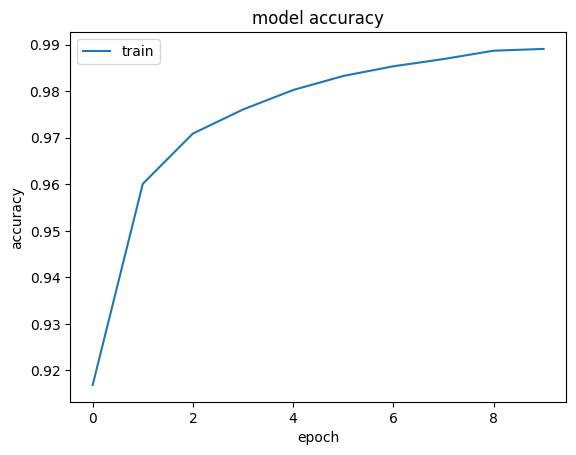

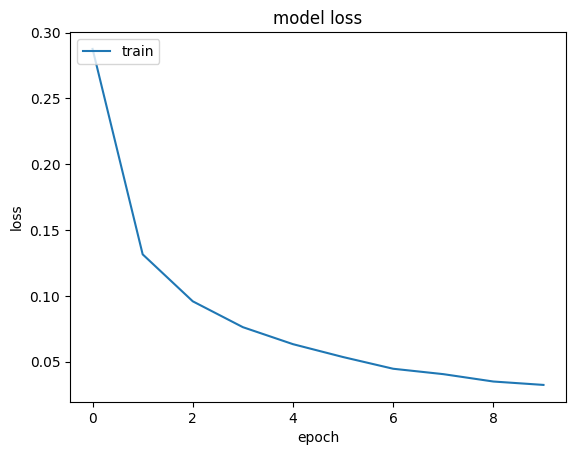

In [15]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Task 6: Build and train a simple CNN model and compare it with the Dense model (3 points)
Which one is better and why (compare the testing accuracy)

### Build, train, and evaluate a simplle CNN model
### Reference: https://keras.io/examples/vision/mnist_convnet/ (2 points)

[Note] The CNN model architecture (and learning process configuration) can be idential to the one in the reference page.

In [22]:
import numpy as np
import keras
from keras import layers

In [23]:
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [24]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 64)        640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        18464     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 800)               0         
                                                                 
 dropout (Dropout)           (None, 800)              

In [25]:
batch_size = 128
epochs = 10

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/10
422/422 [==============================] - 55s 129ms/step - loss: 0.4307 - accuracy: 0.8652 - val_loss: 0.0880 - val_accuracy: 0.9773
Epoch 2/10
422/422 [==============================] - 54s 128ms/step - loss: 0.1359 - accuracy: 0.9585 - val_loss: 0.0611 - val_accuracy: 0.9843
Epoch 3/10
422/422 [==============================] - 51s 120ms/step - loss: 0.1037 - accuracy: 0.9677 - val_loss: 0.0494 - val_accuracy: 0.9865
Epoch 4/10
422/422 [==============================] - 47s 112ms/step - loss: 0.0870 - accuracy: 0.9731 - val_loss: 0.0441 - val_accuracy: 0.9877
Epoch 5/10
422/422 [==============================] - 49s 115ms/step - loss: 0.0758 - accuracy: 0.9767 - val_loss: 0.0415 - val_accuracy: 0.9882
Epoch 6/10
422/422 [==============================] - 48s 114ms/step - loss: 0.0718 - accuracy: 0.9778 - val_loss: 0.0413 - val_accuracy: 0.9890
Epoch 7/10
422/422 [==============================] - 54s 127ms/step - loss: 0.0642 - accuracy: 0.9807 - val_loss: 0.0356 - val_ac

In [26]:
score = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


313/313 - 2s - loss: 0.0284 - accuracy: 0.9903 - 2s/epoch - 7ms/step
Test loss: 0.028435256332159042
Test accuracy: 0.9902999997138977


Discuss what you learn from comparing the Dense model and the CNN model (1 point)

Your answers here:

When we dive into the world of image processing, particularly tasks like identifying handwritten digits in the MNIST dataset, the distinction between Dense layers and Convolutional Neural Network (CNN) models offers some fascinating insights. Dense models, with their fully connected layers, treat each pixel of an image independently, not taking into account the spatial relationship between pixels. This means they might not be as effective for images where the arrangement and patterns of pixels—like the shapes and edges that form a number—are key to recognizing what's depicted. On the other hand, CNNs thrive on this spatial complexity. They apply filters that pick up on local patterns, such as textures and lines, early on and can recognize more complex features as the data moves deeper into the network. This ability to understand the spatial hierarchy makes CNNs particularly adept at tasks involving image data.

Moreover, the structural differences between these two types of models have significant implications for their performance and efficiency. Dense networks, with a web of connections where every input is linked to every output, can quickly grow in size, leading to potential overfitting and a hefty computational load, especially with larger images. Conversely, CNNs are much more efficient, thanks to their shared weights and fewer connections, allowing them to handle larger images without as much computational strain. They’re also better at extracting and learning features autonomously, making them more robust against variations in new data they haven't seen before. While Dense models have their place, particularly in simpler tasks or as components within more complex systems, CNNs stand out for image-related projects, offering superior efficiency, the ability to learn and extract features directly from the visual data, and better overall performance. This comparison underscores the importance of choosing the right model architecture for your specific task, with CNNs being the go-to for image processing challenges.